In [3]:
!pip install braindecode moabb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.7/837.7 kB 11.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 72.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.6/153.6 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.0/92.0 kB 3.6 MB/s eta 0:00:00


In [4]:
# Authors: Maciej Sliwowski <maciek.sliwowski@gmail.com>
#          Mohammed Fattouh <mo.fattouh@gmail.com>
#
# License: BSD (3-clause)

In [5]:
import numpy as np

from braindecode.datasets import BCICompetitionIVDataset4

subject_id = 1
dataset = BCICompetitionIVDataset4(subject_ids=[subject_id])

Attempting to create new mne-python configuration file:
/root/.mne/mne-python.json
Could not read the /root/.mne/mne-python.json json file during the writing. Assuming it is empty. Got: Expecting value: line 1 column 1 (char 0)


/usr/local/lib/python3.12/dist-packages/moabb/datasets/download.py:97: RuntimeWarning: Setting non-standard config type: "MNE_DATASETS_BCICOMPETITIONIVDATASET4_PATH"
  set_config(key, get_config("MNE_DATA"))
SHA256 hash of downloaded file: 04c237ab33f25eb11c93d4cea69693823693d16ef145d4a034a77ddae6238ebb
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if it is downloaded again in the future.


Creating RawArray with float64 data, n_channels=67, n_times=400000
    Range : 0 ... 399999 =      0.000 ...   399.999 secs
Ready.
Creating RawArray with float64 data, n_channels=67, n_times=200000
    Range : 0 ... 199999 =      0.000 ...   199.999 secs
Ready.


### Preprocessing




In [6]:
from braindecode.preprocessing import (
    Preprocessor,
    exponential_moving_standardize,
    preprocess,
)

low_cut_hz = 1.0  
high_cut_hz = 200.0 

factor_new = 1e-3
init_block_size = 1000

preprocess(dataset, [Preprocessor("crop", tmin=0, tmax=30)])

/usr/local/lib/python3.12/dist-packages/braindecode/preprocessing/preprocess.py:78: UserWarning: apply_on_array can only be True if fn is a callable function. Automatically correcting to apply_on_array=False.
  warn(


<BaseConcatDataset | 2 RawDataset(s) | 60002 total samples>
  Sfreq*: 1000.0 Hz
  Channels*: 67 (62 ECOG, 5 MISC)
  Ch. names*: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, ... (+57 more)
  Duration*: 30.0 s
  (* from first recording)
  Description: 2 recordings × 3 columns [subject, file_name, session]

In [7]:
preprocessors = [
    Preprocessor("pick_types", ecog=True, misc=True),
    Preprocessor(lambda x: x / 1e6, picks="ecog"), 
    Preprocessor("filter", l_freq=low_cut_hz, h_freq=high_cut_hz),  
    Preprocessor(
        exponential_moving_standardize, 
        factor_new=factor_new,
        init_block_size=init_block_size,
        picks="ecog",
    ),
]

preprocess(dataset, preprocessors)

sfreq = dataset.datasets[0].raw.info["sfreq"]
assert all([ds.raw.info["sfreq"] == sfreq for ds in dataset.datasets])

target_sfreq = dataset.datasets[0].raw.info["temp"]["target_sfreq"]

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 2e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 200.00 Hz
- Upper transition bandwidth: 50.00 Hz (-6 dB cutoff frequency: 225.00 Hz)
- Filter length: 3301 samples (3.301 s)



/usr/local/lib/python3.12/dist-packages/braindecode/preprocessing/preprocess.py:78: UserWarning: apply_on_array can only be True if fn is a callable function. Automatically correcting to apply_on_array=False.
  warn(
/usr/local/lib/python3.12/dist-packages/braindecode/preprocessing/preprocess.py:76: UserWarning: Preprocessing choices with lambda functions cannot be saved.
  warn("Preprocessing choices with lambda functions cannot be saved.")


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 2e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 200.00 Hz
- Upper transition bandwidth: 50.00 Hz (-6 dB cutoff frequency: 225.00 Hz)
- Filter length: 3301 samples (3.301 s)



### Cut Compute Windows




In [8]:
from braindecode.preprocessing import create_windows_from_target_channels

windows_dataset = create_windows_from_target_channels(
    dataset, window_size_samples=1000, preload=False, last_target_only=True
)

In [9]:
windows_dataset.target_transform = lambda x: x[0:1]

In [11]:
subsets = windows_dataset.split("session")
train_set = subsets["train"]
test_set = subsets["test"]

In [12]:
import torch
from sklearn.model_selection import train_test_split

idx_train, idx_valid = train_test_split(
    np.arange(len(train_set)), random_state=100, test_size=0.2, shuffle=False
)

valid_set = torch.utils.data.Subset(train_set, idx_valid)
train_set = torch.utils.data.Subset(train_set, idx_train)

## Create model




In [13]:
import torch
from braindecode.models import EEGNet
from braindecode.util import set_random_seeds

cuda = torch.cuda.is_available()
device = "cuda" if cuda else "cpu"

# Reproducibility
seed = 20200220
set_random_seeds(seed=seed, cuda=cuda)

n_out_chans = train_set[0][1].shape[0]
n_chans = train_set[0][0].shape[0]
n_times = train_set[0][0].shape[1]

model = EEGNet(
    n_chans=n_chans,
    n_outputs=n_out_chans,
    n_times=n_times,
    final_conv_length="auto",
    drop_prob=0.25,
)

model = model.to(device)
print(model)
print(f"Using {device}; input shape = ({n_chans}, {n_times}); outputs = {n_out_chans}")


Layer (type (var_name):depth-idx)                            Input Shape               Output Shape              Param #                   Kernel Shape
EEGNet (EEGNet)                                              [1, 62, 1000]             [1, 1]                    --                        --
├─Ensure4d (ensuredims): 1-1                                 [1, 62, 1000]             [1, 62, 1000, 1]          --                        --
├─Rearrange (dimshuffle): 1-2                                [1, 62, 1000, 1]          [1, 1, 62, 1000]          --                        --
├─Conv2d (conv_temporal): 1-3                                [1, 1, 62, 1000]          [1, 8, 62, 1001]          512                       [1, 64]
├─BatchNorm2d (bnorm_temporal): 1-4                          [1, 8, 62, 1001]          [1, 8, 62, 1001]          16                        --
├─ParametrizedConv2dWithConstraint (conv_spatial): 1-5       [1, 8, 62, 1001]          [1, 16, 1, 1001]          --                  

## Training




In [14]:
from mne import set_log_level
from skorch.callbacks import EarlyStopping, EpochScoring, LRScheduler
from skorch.helper import predefined_split

from braindecode import EEGRegressor

lr = 1e-3
weight_decay = 1e-4
batch_size = 64
n_epochs = 25


def pearson_r_score(net, dataset, y):
    preds = net.predict(dataset)
    corr_coeffs = []
    for i in range(y.shape[1]):
        r = np.corrcoef(y[:, i], preds[:, i])[0, 1]
        corr_coeffs.append(0.0 if np.isnan(r) else r)
    return float(np.mean(corr_coeffs))


regressor = EEGRegressor(
    model,
    criterion=torch.nn.MSELoss,
    optimizer=torch.optim.AdamW,
    train_split=predefined_split(valid_set),
    optimizer__lr=lr,
    optimizer__weight_decay=weight_decay,
    batch_size=batch_size,
    max_epochs=n_epochs,
    callbacks=[
        "r2",
        (
            "valid_pearson_r",
            EpochScoring(
                pearson_r_score,
                lower_is_better=False,
                on_train=False,
                name="valid_pearson_r",
            ),
        ),
        (
            "train_pearson_r",
            EpochScoring(
                pearson_r_score,
                lower_is_better=False,
                on_train=True,
                name="train_pearson_r",
            ),
        ),
        ("lr_scheduler", LRScheduler("CosineAnnealingLR", T_max=n_epochs)),
        ("early_stopping", EarlyStopping(monitor="valid_loss", patience=8, load_best=True)),
    ],
    device=device,
    verbose=1,
)
set_log_level(verbose="WARNING")


In [15]:
regressor.fit(train_set, y=None)


  epoch    train_loss    train_pearson_r    train_r2    valid_loss    valid_pearson_r    valid_r2      lr     dur
-------  ------------  -----------------  ----------  ------------  -----------------  ----------  ------  ------
      1        0.8181            -0.0031      0.0139        3.0382            -0.0917     -0.3851  0.0010  9.1817
      2        0.6958             0.2147      0.0262        3.0471            -0.1541     -0.3891  0.0010  8.8632
      3        0.6366             0.3160      0.0396        3.0412            -0.1359     -0.3864  0.0010  8.8943
      4        0.6218             0.3487      0.0595        3.0356            -0.1128     -0.3839  0.0010  8.9018
      5        0.5592             0.4463      0.0791        3.0473            -0.0965     -0.3892  0.0009  8.8765
      6        0.5449             0.4697      0.1042        3.0690            -0.0786     -0.3991  0.0009  8.8820
      7        0.4658             0.5774      0.1332        3.0983            -0.0732   

In [16]:
regressor.save_params(f_params="eegnet_bcic_iv_4_params.pt")
print("Saved trained EEGNet parameters locally.")


Saved trained EEGNet parameters locally.


Obtaining predictions and targets for the test, train, and validation dataset



In [17]:
preds_test = regressor.predict(test_set)
y_test = np.stack([data[1] for data in test_set])
preds_train = regressor.predict(train_set)
y_train = np.stack([data[1] for data in train_set])
preds_valid = regressor.predict(valid_set)
y_valid = np.stack([data[1] for data in valid_set])

## Plot Results



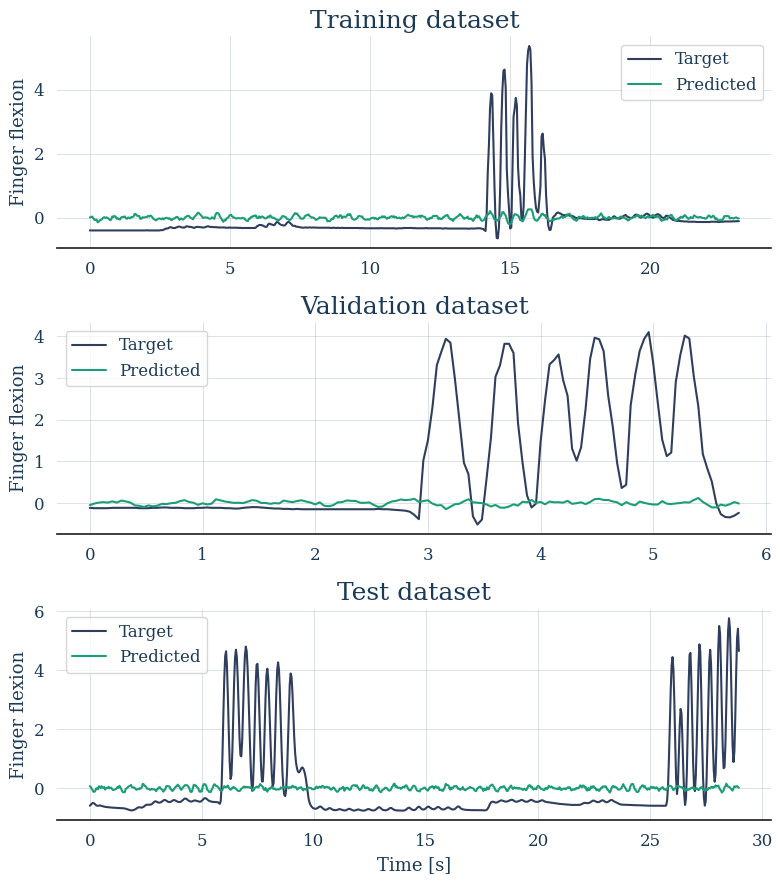

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.lines import Line2D

fig, axes = plt.subplots(3, 1, figsize=(8, 9))

axes[0].set_title("Training dataset")
axes[0].plot(
    np.arange(0, y_train.shape[0]) / target_sfreq, y_train[:, 0], label="Target"
)
axes[0].plot(
    np.arange(0, preds_train.shape[0]) / target_sfreq,
    preds_train[:, 0],
    label="Predicted",
)
axes[0].set_ylabel("Finger flexion")
axes[0].legend()

axes[1].set_title("Validation dataset")
axes[1].plot(
    np.arange(0, y_valid.shape[0]) / target_sfreq, y_valid[:, 0], label="Target"
)
axes[1].plot(
    np.arange(0, preds_valid.shape[0]) / target_sfreq,
    preds_valid[:, 0],
    label="Predicted",
)
axes[1].set_ylabel("Finger flexion")
axes[1].legend()

axes[2].set_title("Test dataset")
axes[2].plot(np.arange(0, y_test.shape[0]) / target_sfreq, y_test[:, 0], label="Target")
axes[2].plot(
    np.arange(0, preds_test.shape[0]) / target_sfreq,
    preds_test[:, 0],
    label="Predicted",
)
axes[2].set_xlabel("Time [s]")
axes[2].set_ylabel("Finger flexion")
axes[2].legend()
plt.tight_layout()

In [19]:
corr_coeffs = []
for dim in range(y_test.shape[1]):
    corr_coeffs.append(np.corrcoef(preds_test[:, dim], y_test[:, dim])[0, 1])
print("Correlation coefficient for each dimension: ", np.round(corr_coeffs, 2))

Correlation coefficient for each dimension:  [0.05]


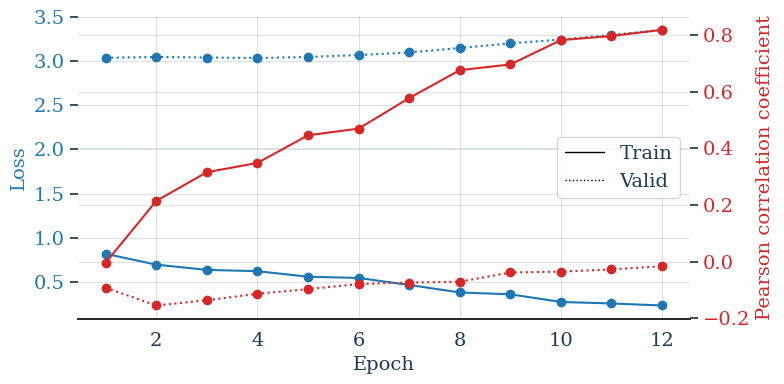

In [20]:
results_columns = ["train_loss", "valid_loss", "train_pearson_r", "valid_pearson_r"]
df = pd.DataFrame(
    regressor.history[:, results_columns],
    columns=results_columns,
    index=regressor.history[:, "epoch"],
)

fig, ax1 = plt.subplots(figsize=(8, 4))
df.loc[:, ["train_loss", "valid_loss"]].plot(
    ax=ax1, style=["-", ":"], marker="o", color="tab:blue", legend=False, fontsize=14
)

ax1.tick_params(axis="y", labelcolor="tab:blue", labelsize=14)
ax1.set_ylabel("Loss", color="tab:blue", fontsize=14)

ax2 = ax1.twinx()  

df.loc[:, ["train_pearson_r", "valid_pearson_r"]].plot(
    ax=ax2, style=["-", ":"], marker="o", color="tab:red", legend=False
)
ax2.tick_params(axis="y", labelcolor="tab:red", labelsize=14)
ax2.set_ylabel("Pearson correlation coefficient", color="tab:red", fontsize=14)
ax1.set_xlabel("Epoch", fontsize=14)

handles = []
handles.append(
    Line2D([0], [0], color="black", linewidth=1, linestyle="-", label="Train")
)
handles.append(
    Line2D([0], [0], color="black", linewidth=1, linestyle=":", label="Valid")
)
plt.legend(handles, [h.get_label() for h in handles], fontsize=14, loc="center right")
plt.tight_layout()

.. include:: /links.inc

